### Load the data

In [44]:
import pandas as pd

In [45]:
df = pd.read_csv('iris-data.xls')

In [46]:
df.shape

(150, 5)

In [47]:
df.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


**Plot the data to see the relationship between sepal length and sepal width**

In [48]:
df.describe()

,sepal length,sepal width,petal length,petal width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [49]:
df.isnull().sum()

sepal length    0
sepal width     0
petal length    0
petal width     0
class           0
dtype: int64

**Creating dependent and Independent variables**

In [50]:
X = df.drop('class', axis=1)

In [51]:
y = df['class']

##### check the shape of X and y

In [52]:
X.shape

(150, 4)

In [53]:
y.shape

(150,)

**Split the data into training and testing sets**

In [54]:
from sklearn.model_selection import train_test_split

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=4)

In [56]:
X_train.shape

(112, 4)

In [57]:
y_train.shape

(112,)

In [58]:
X_test.shape

(38, 4)

In [59]:
y_test.shape

(38,)

**Train the linear regression model using the training data**

In [60]:
from sklearn.tree import DecisionTreeClassifier

In [61]:
model = DecisionTreeClassifier(criterion='entropy')

In [62]:
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

In [63]:
y_pred = model.predict(X_test)

In [64]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score

In [65]:
accuracy_score(y_test, y_pred)

0.9736842105263158

In [66]:
precision_score(y_test, y_pred, average='weighted')

0.9757085020242916

In [67]:
confusion_matrix(y_test, y_pred)

array([[18,  0,  0],
       [ 0,  7,  1],
       [ 0,  0, 12]])

In [68]:
f1_score(y_test, y_pred, average='weighted')

0.9733333333333333

In [69]:
model.score(X_test, y_test)

0.9736842105263158

In [70]:
model.feature_importances_

array([0.        , 0.0156062 , 0.07501716, 0.90937664])

In [74]:
first_test_input = X_test.iloc[7]
# %%
actual_output = y_test.iloc[7]
# %%
predicted_output = model.predict(first_test_input.values.reshape(1, -1))
# %%
print(f"Predicted Output: {predicted_output}")
# %%
print(f"Actual Output: {actual_output}")
# %%
assert predicted_output == actual_output
# %%

##### #%% md


Predicted Output: ['Iris-setosa']
Actual Output: Iris-setosa


C:\Users\shaki\PycharmProjects\JupyterProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


#### plot the tree

In [72]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

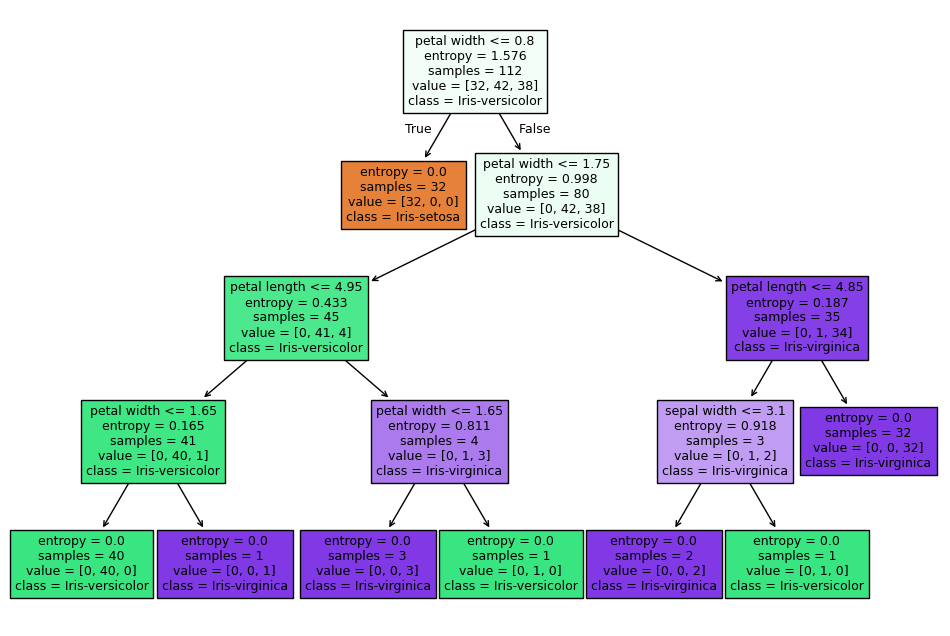

In [73]:
plt.figure(figsize=(12, 8))
plot_tree(model, filled=True, feature_names=X.columns, class_names=model.classes_)
plt.show()

#### cross validation

In [75]:
from sklearn.model_selection import cross_val_score

In [76]:
cv_model = DecisionTreeClassifier(random_state=0)

In [77]:
cv_scores = cross_val_score(cv_model, X, y, cv=5)

In [78]:
print("Cross-validation scores:", cv_scores)

Cross-validation scores: [0.96666667 0.96666667 0.9        0.96666667 1.        ]


In [79]:
print("Average cross-validation score:", cv_scores.mean())

Average cross-validation score: 0.9600000000000002


In [80]:
print("standard deviation: ", cv_scores.std())

standard deviation:  0.03265986323710903
